## Import Python Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
from skimage.feature import hog, local_binary_pattern
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("Success")

2026-08-02 21:47:09.006839: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Success


## Data Path Loading

In [2]:
dataset_path = "/Users/Downloads/resized"

In [3]:
classes = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Classes Found:\n")

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    print(f"{cls} ---> {len(os.listdir(folder))} images")

Classes Found:

healthy ---> 155 images
segatoka ---> 320 images
xamthomonas ---> 814 images


In [4]:
image_count = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    image_count[cls] = len(os.listdir(folder))

df_count = pd.DataFrame(
    image_count.items(),
    columns=["Disease","Images"]
)

df_count

,Disease,Images
0,healthy,155
1,segatoka,320
2,xamthomonas,814


## Class Distribution

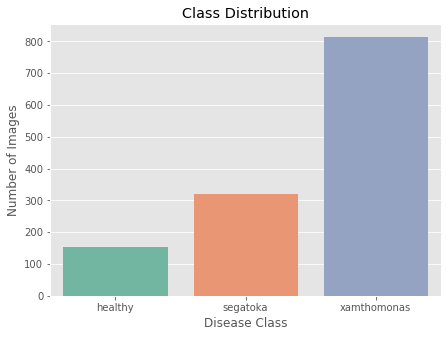

In [5]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_count,
    x="Disease",
    y="Images",
    palette="Set2"
)

plt.title("Class Distribution")

plt.xlabel("Disease Class")

plt.ylabel("Number of Images")

plt.show()

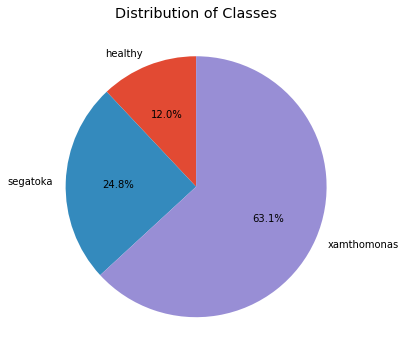

In [6]:
plt.figure(figsize=(6,6))

plt.pie(
    df_count["Images"],
    labels=df_count["Disease"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Classes")

plt.show()

## Visualizations

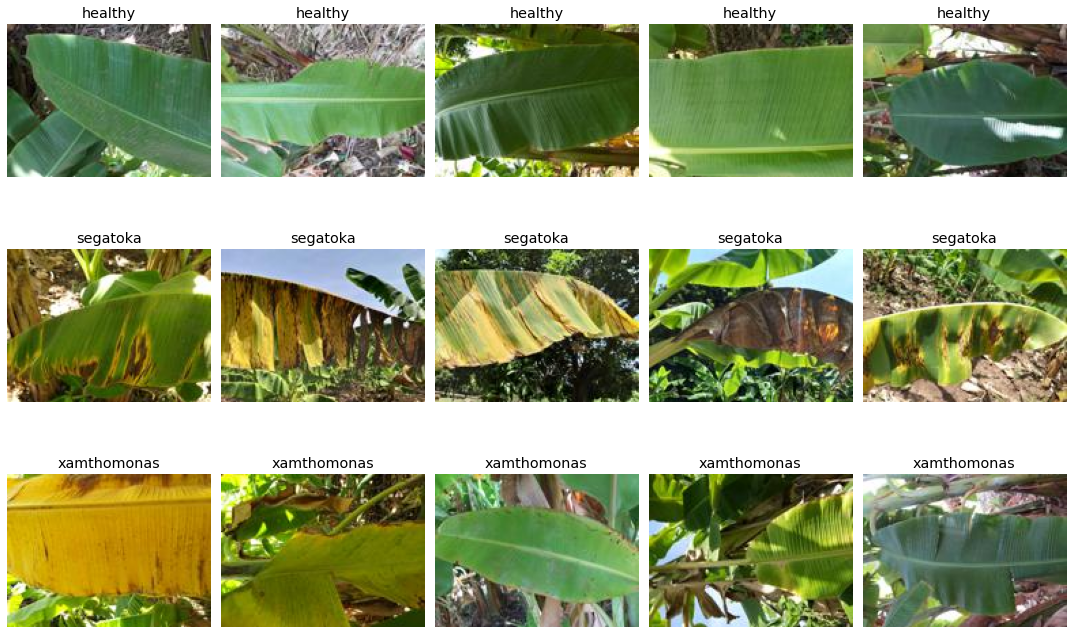

In [7]:
fig, axes = plt.subplots(3,5, figsize=(15,10))

for row, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    images = np.random.choice(os.listdir(folder),5)

    for col,img_name in enumerate(images):

        img_path = os.path.join(folder,img_name)

        image = cv2.imread(img_path)

        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        axes[row,col].imshow(image)

        axes[row,col].set_title(cls)

        axes[row,col].axis("off")

plt.tight_layout()

plt.show()

In [8]:
widths=[]

heights=[]

for cls in classes:

    folder=os.path.join(dataset_path,cls)

    for img in os.listdir(folder):

        path=os.path.join(folder,img)

        image=cv2.imread(path)

        h,w=image.shape[:2]

        widths.append(w)

        heights.append(h)

print("Minimum Width :",min(widths))
print("Maximum Width :",max(widths))

print()

print("Minimum Height :",min(heights))
print("Maximum Height :",max(heights))

Minimum Width : 150
Maximum Width : 150

Minimum Height : 113
Maximum Height : 113


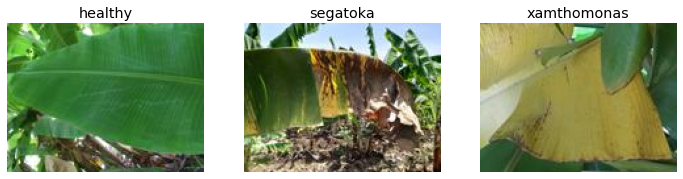

In [9]:
sample_images=[]

for cls in classes:

    folder=os.path.join(dataset_path,cls)

    img=os.listdir(folder)[0]

    path=os.path.join(folder,img)

    image=cv2.imread(path)

    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    sample_images.append(image)

fig,ax=plt.subplots(1,3,figsize=(12,4))

for i in range(3):

    ax[i].imshow(sample_images[i])

    ax[i].set_title(classes[i])

    ax[i].axis("off")

plt.show()

## Data Pre-processing

In [10]:
IMG_SIZE = 128

In [11]:
def preprocess_image(path):

    image=cv2.imread(path)

    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    image=cv2.resize(image,(IMG_SIZE,IMG_SIZE))

    image=cv2.GaussianBlur(image,(3,3),0)

    image=image.astype("float32")/255.0

    return image

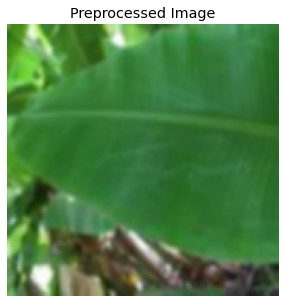

In [12]:
folder=os.path.join(dataset_path,classes[0])

img=os.listdir(folder)[0]

path=os.path.join(folder,img)

image=preprocess_image(path)

plt.figure(figsize=(5,5))

plt.imshow(image)

plt.title("Preprocessed Image")

plt.axis("off")

plt.show()

In [13]:
images=[]

labels=[]

label_dict={
    "healthy":0,
    "segatoka":1,
    "xamthomonas":2
}

for cls in classes:

    folder=os.path.join(dataset_path,cls)

    for img in os.listdir(folder):

        path=os.path.join(folder,img)

        image=preprocess_image(path)

        images.append(image)

        labels.append(label_dict[cls])

images=np.array(images)

labels=np.array(labels)

print(images.shape)

print(labels.shape)

(1289, 128, 128, 3)
(1289,)


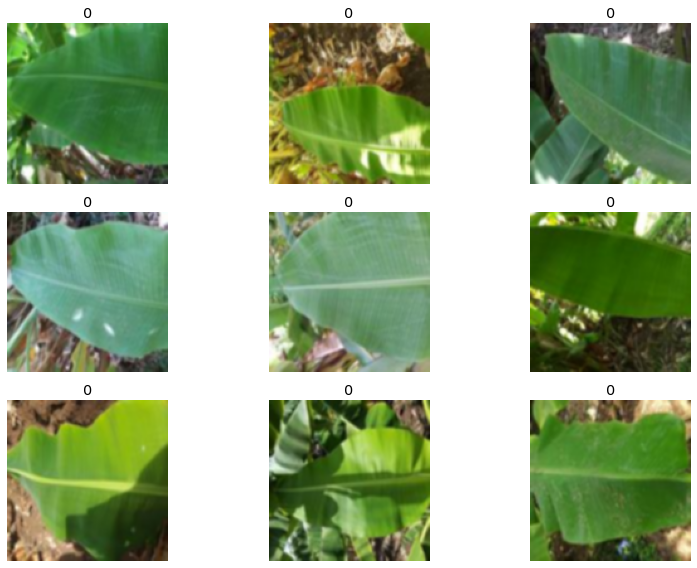

In [14]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(labels[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [15]:
mapping={

0:"Healthy",

1:"Segatoka",

2:"Xamthomonas"

}

mapping

{0: 'Healthy', 1: 'Segatoka', 2: 'Xamthomonas'}

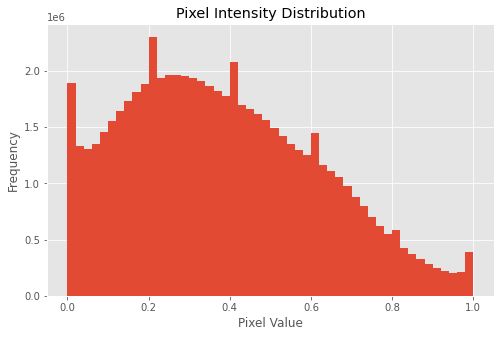

In [16]:
plt.figure(figsize=(8,5))

plt.hist(images.flatten(),bins=50)

plt.title("Pixel Intensity Distribution")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(

images,

labels,

test_size=0.20,

random_state=42,

stratify=labels

)

print(X_train.shape)

print(X_test.shape)

(1031, 128, 128, 3)
(258, 128, 128, 3)


In [18]:
dataset_info=pd.DataFrame({

"Training Images":[len(X_train)],

"Testing Images":[len(X_test)],

"Image Size":[IMG_SIZE],

"Classes":[len(classes)]

})

dataset_info

,Training Images,Testing Images,Image Size,Classes
0,1031,258,128,3


## Feature Extraction

In [19]:
def extract_hog_features(image):

    gray = cv2.cvtColor(
        (image * 255).astype("uint8"),
        cv2.COLOR_RGB2GRAY
    )

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        visualize=False
    )

    return features

In [20]:
def extract_lbp_features(image):

    gray = cv2.cvtColor(
        (image * 255).astype("uint8"),
        cv2.COLOR_RGB2GRAY
    )

    radius = 2
    n_points = 16

    lbp = local_binary_pattern(
        gray,
        n_points,
        radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")

    hist /= (hist.sum() + 1e-7)

    return hist

In [21]:
hog_features = []

for img in images:

    hog_vector = extract_hog_features(img)

    lbp_vector = extract_lbp_features(img)

    feature_vector = np.concatenate(
        [hog_vector, lbp_vector]
    )

    hog_features.append(feature_vector)

hog_features = np.array(hog_features)

print(hog_features.shape)

(1289, 8118)


## Train-Test-Split

In [22]:
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(

    hog_features,

    labels,

    test_size=0.20,

    random_state=42,

    stratify=labels

)

print(X_train_ml.shape)

print(X_test_ml.shape)

(1031, 8118)
(258, 8118)


In [23]:
scaler = StandardScaler()

X_train_ml = scaler.fit_transform(X_train_ml)

X_test_ml = scaler.transform(X_test_ml)

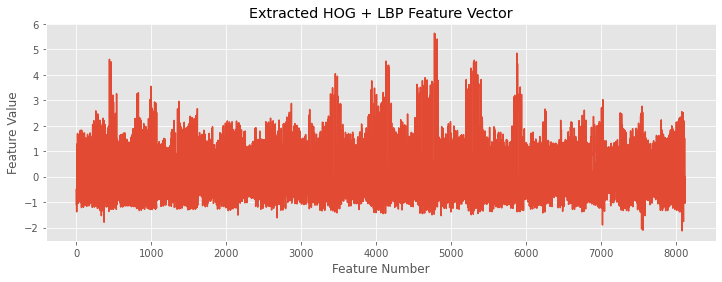

In [24]:
plt.figure(figsize=(12,4))

plt.plot(X_train_ml[0])

plt.title("Extracted HOG + LBP Feature Vector")

plt.xlabel("Feature Number")

plt.ylabel("Feature Value")

plt.show()

## SVM

In [25]:
svm = SVC(

    kernel='rbf',

    probability=True,

    random_state=42

)

svm.fit(

    X_train_ml,

    y_train_ml

)

svm_prediction = svm.predict(X_test_ml)

In [26]:
svm_accuracy = accuracy_score(
    y_test_ml,
    svm_prediction
)

svm_precision = precision_score(
    y_test_ml,
    svm_prediction,
    average="weighted"
)

svm_recall = recall_score(
    y_test_ml,
    svm_prediction,
    average="weighted"
)

svm_f1 = f1_score(
    y_test_ml,
    svm_prediction,
    average="weighted"
)

print("Accuracy :", svm_accuracy)

print("Precision :", svm_precision)

print("Recall :", svm_recall)

print("F1 Score :", svm_f1)

Accuracy : 0.7054263565891473
Precision : 0.6370100234309679
Recall : 0.7054263565891473
F1 Score : 0.6392252246597412


In [27]:
print(classification_report(

    y_test_ml,

    svm_prediction,

    target_names=list(mapping.values())

))

              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00        31
    Segatoka       0.81      0.39      0.53        64
 Xamthomonas       0.69      0.96      0.81       163

    accuracy                           0.71       258
   macro avg       0.50      0.45      0.44       258
weighted avg       0.64      0.71      0.64       258



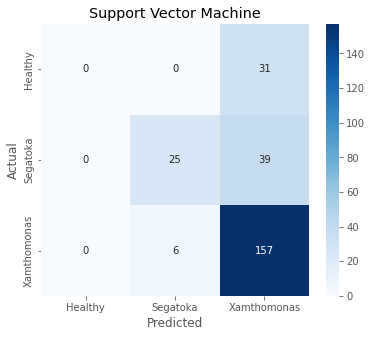

In [28]:
cm = confusion_matrix(
    y_test_ml,
    svm_prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=list(mapping.values()),

    yticklabels=list(mapping.values())

)

plt.title("Support Vector Machine")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Random Forest

In [29]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    max_depth=None

)

rf.fit(

    X_train_ml,

    y_train_ml

)

rf_prediction = rf.predict(X_test_ml)

In [30]:
rf_accuracy = accuracy_score(

    y_test_ml,

    rf_prediction

)

rf_precision = precision_score(

    y_test_ml,

    rf_prediction,

    average="weighted"

)

rf_recall = recall_score(

    y_test_ml,

    rf_prediction,

    average="weighted"

)

rf_f1 = f1_score(

    y_test_ml,

    rf_prediction,

    average="weighted"

)

print("Accuracy :", rf_accuracy)

print("Precision :", rf_precision)

print("Recall :", rf_recall)

print("F1 Score :", rf_f1)

Accuracy : 0.6705426356589147
Precision : 0.6114933247200689
Recall : 0.6705426356589147
F1 Score : 0.5832325811283965


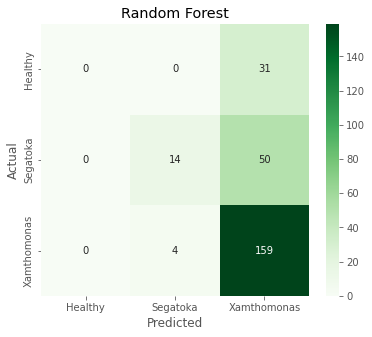

In [31]:
cm = confusion_matrix(

    y_test_ml,

    rf_prediction

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    cmap="Greens",

    fmt="d",

    xticklabels=list(mapping.values()),

    yticklabels=list(mapping.values())

)

plt.title("Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## KNN

In [32]:
knn = KNeighborsClassifier(

    n_neighbors=5

)

knn.fit(

    X_train_ml,

    y_train_ml

)

knn_prediction = knn.predict(X_test_ml)

In [33]:
knn_accuracy = accuracy_score(

    y_test_ml,

    knn_prediction

)

knn_precision = precision_score(

    y_test_ml,

    knn_prediction,

    average="weighted"

)

knn_recall = recall_score(

    y_test_ml,

    knn_prediction,

    average="weighted"

)

knn_f1 = f1_score(

    y_test_ml,

    knn_prediction,

    average="weighted"

)

print("Accuracy :", knn_accuracy)

print("Precision :", knn_precision)

print("Recall :", knn_recall)

print("F1 Score :", knn_f1)

Accuracy : 0.6705426356589147
Precision : 0.659244835132228
Recall : 0.6705426356589147
F1 Score : 0.6498705590483106


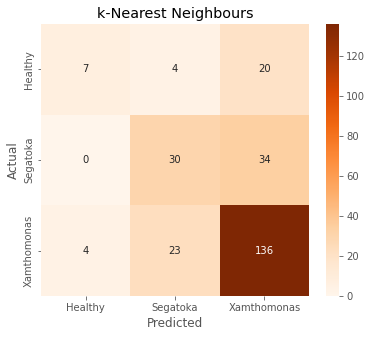

In [34]:
cm = confusion_matrix(

    y_test_ml,

    knn_prediction

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Oranges",

    xticklabels=list(mapping.values()),

    yticklabels=list(mapping.values())

)

plt.title("k-Nearest Neighbours")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [35]:
comparison = pd.DataFrame({

    "Model":[

        "Support Vector Machine",

        "Random Forest",

        "K-Nearest Neighbours"

    ],

    "Accuracy":[

        svm_accuracy,

        rf_accuracy,

        knn_accuracy

    ],

    "Precision":[

        svm_precision,

        rf_precision,

        knn_precision

    ],

    "Recall":[

        svm_recall,

        rf_recall,

        knn_recall

    ],

    "F1 Score":[

        svm_f1,

        rf_f1,

        knn_f1

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Support Vector Machine,0.705426,0.637010,0.705426,0.639225
1,Random Forest,0.670543,0.611493,0.670543,0.583233
2,K-Nearest Neighbours,0.670543,0.659245,0.670543,0.649871


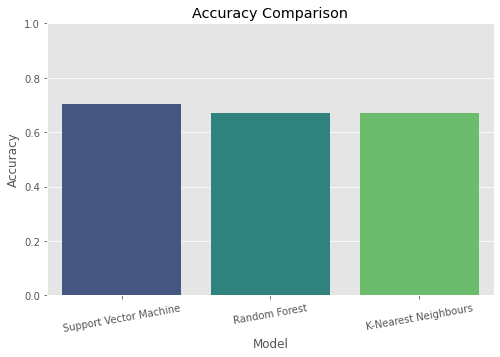

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=comparison,

    x="Model",

    y="Accuracy",

    palette="viridis"

)

plt.ylim(0,1)

plt.title("Accuracy Comparison")

plt.xticks(rotation=10)

plt.show()

In [37]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print(best_model)

                    Model  Accuracy  Precision    Recall  F1 Score
0  Support Vector Machine  0.705426   0.637010  0.705426  0.639225
1           Random Forest  0.670543   0.611493  0.670543  0.583233
2    K-Nearest Neighbours  0.670543   0.659245  0.670543  0.649871


In [38]:
joblib.dump(

    rf,

    "RandomForest_Banana.pkl"

)

joblib.dump(

    scaler,

    "Scaler.pkl"

)

print("Traditional ML Model Saved Successfully")

Traditional ML Model Saved Successfully


## CNN

In [39]:
y_train_cat = to_categorical(y_train, num_classes=3)

y_test_cat = to_categorical(y_test, num_classes=3)

print(y_train_cat.shape)

print(y_test_cat.shape)

(1031, 3)
(258, 3)


In [40]:
train_generator = ImageDataGenerator(

    rotation_range=20,

    width_shift_range=0.15,

    height_shift_range=0.15,

    zoom_range=0.20,

    shear_range=0.15,

    horizontal_flip=True,

    fill_mode='nearest'

)

train_generator.fit(X_train)

In [41]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

In [42]:
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=5,

    verbose=1
)

In [43]:
checkpoint = ModelCheckpoint(

    "Best_Banana_CNN.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)

In [44]:
from tensorflow.keras.layers import Input

cnn = Sequential([

    Input(shape=(128,128,3)),

    Conv2D(
        32,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D(),

    Dropout(0.25),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D(),

    Dropout(0.25),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D(),

    Dropout(0.30),

    Flatten(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.40),

    Dense(
        3,
        activation="softmax"
    )

])

In [45]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,699 (24.86 MB)

 Trainable params: 6,517,251 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [46]:
cnn.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [47]:
history = cnn.fit(

    train_generator.flow(

        X_train,

        y_train_cat,

        batch_size=32

    ),

    validation_data=(

        X_test,

        y_test_cat

    ),

    epochs=50,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    verbose=1
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5256 - loss: 8.3957
Epoch 1: val_accuracy improved from -inf to 0.24806, saving model to Best_Banana_CNN.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5267 - loss: 8.3157 - val_accuracy: 0.2481 - val_loss: 14.6079 - learning_rate: 0.0010
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6038 - loss: 1.3414
Epoch 2: val_accuracy did not improve from 0.24806
33/33 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.6043 - loss: 1.3358 - val_accuracy: 0.2481 - val_loss: 24.8504 - learning_rate: 0.0010
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6490 - loss: 0.8413
Epoch 3: val_accuracy improved from 0.24806 to 0.42248, saving model to Best_Banana_CNN.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6493 - loss: 0.8395 - val_accuracy: 0.4225 - val_loss: 8.3823 - learning_rate: 0.0010
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6455 - loss: 0.7083
Epoch 4: val_

In [48]:
loss, accuracy = cnn.evaluate(

    X_test,

    y_test_cat,

    verbose=0
)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

Test Loss : 0.5275089740753174
Test Accuracy : 0.7558139562606812


In [49]:
cnn_prob = cnn.predict(X_test)

cnn_prediction = np.argmax(

    cnn_prob,

    axis=1
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 391ms/step


In [50]:
print(

    classification_report(

        y_test,

        cnn_prediction,

        target_names=list(mapping.values())

    )

)

              precision    recall  f1-score   support

     Healthy       0.47      0.23      0.30        31
    Segatoka       0.88      0.59      0.71        64
 Xamthomonas       0.75      0.92      0.83       163

    accuracy                           0.76       258
   macro avg       0.70      0.58      0.61       258
weighted avg       0.75      0.76      0.73       258



In [51]:
cnn_accuracy = accuracy_score(

    y_test,

    cnn_prediction
)

cnn_precision = precision_score(

    y_test,

    cnn_prediction,

    average="weighted"
)

cnn_recall = recall_score(

    y_test,

    cnn_prediction,

    average="weighted"
)

cnn_f1 = f1_score(

    y_test,

    cnn_prediction,

    average="weighted"
)

print("Accuracy :", cnn_accuracy)

print("Precision :", cnn_precision)

print("Recall :", cnn_recall)

print("F1 Score :", cnn_f1)

Accuracy : 0.7558139534883721
Precision : 0.7491271558199628
Recall : 0.7558139534883721
F1 Score : 0.7348971718433418


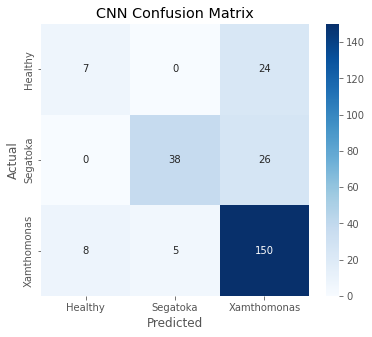

In [52]:
cm = confusion_matrix(

    y_test,

    cnn_prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    cmap="Blues",

    fmt="d",

    xticklabels=list(mapping.values()),

    yticklabels=list(mapping.values())

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("CNN Confusion Matrix")

plt.show()

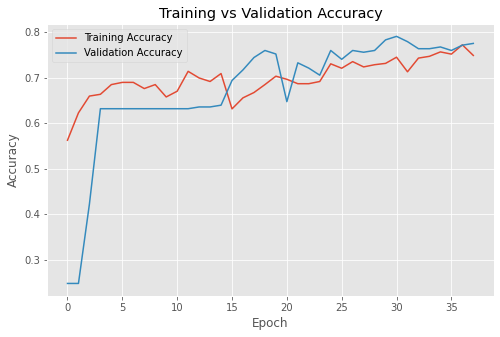

In [53]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history['accuracy'],

    label="Training Accuracy"

)

plt.plot(

    history.history['val_accuracy'],

    label="Validation Accuracy"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

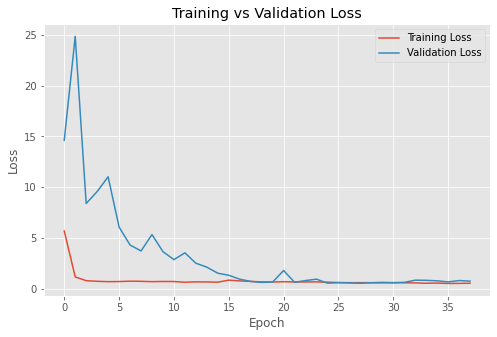

In [54]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history['loss'],

    label="Training Loss"

)

plt.plot(

    history.history['val_loss'],

    label="Validation Loss"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [55]:
cnn.save(

    "BananaLeafCNN.keras"
)

print("CNN Saved Successfully")

CNN Saved Successfully


In [56]:
from tensorflow.keras.models import load_model

loaded_model = load_model(

    "BananaLeafCNN.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully


## Testing

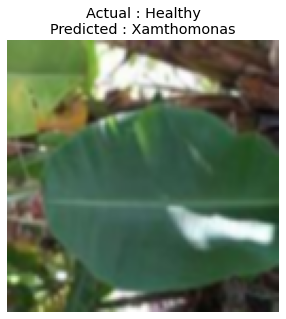

In [57]:
index = np.random.randint(

    len(X_test)
)

sample = X_test[index]

prediction = loaded_model.predict(

    np.expand_dims(sample, axis=0),

    verbose=0
)

predicted_class = np.argmax(prediction)

actual = y_test[index]

plt.figure(figsize=(5,5))

plt.imshow(sample)

plt.axis("off")

plt.title(

    f"Actual : {mapping[actual]}\n"

    f"Predicted : {mapping[predicted_class]}"

)

plt.show()

## All Models Comparison

In [58]:
comparison = pd.DataFrame({

    "Model":[
        "Support Vector Machine",
        "Random Forest",
        "K-Nearest Neighbours",
        "Convolutional Neural Network"
    ],

    "Accuracy":[
        svm_accuracy,
        rf_accuracy,
        knn_accuracy,
        cnn_accuracy
    ],

    "Precision":[
        svm_precision,
        rf_precision,
        knn_precision,
        cnn_precision
    ],

    "Recall":[
        svm_recall,
        rf_recall,
        knn_recall,
        cnn_recall
    ],

    "F1 Score":[
        svm_f1,
        rf_f1,
        knn_f1,
        cnn_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Support Vector Machine,0.705426,0.637010,0.705426,0.639225
1,Random Forest,0.670543,0.611493,0.670543,0.583233
2,K-Nearest Neighbours,0.670543,0.659245,0.670543,0.649871
3,Convolutional Neural Network,0.755814,0.749127,0.755814,0.734897


In [59]:
comparison = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
3,Convolutional Neural Network,0.755814,0.749127,0.755814,0.734897
0,Support Vector Machine,0.705426,0.637010,0.705426,0.639225
1,Random Forest,0.670543,0.611493,0.670543,0.583233
2,K-Nearest Neighbours,0.670543,0.659245,0.670543,0.649871


In [60]:
comparison.to_csv(

    "Model_Comparison.csv",

    index=False

)

print("Comparison Saved.")

Comparison Saved.


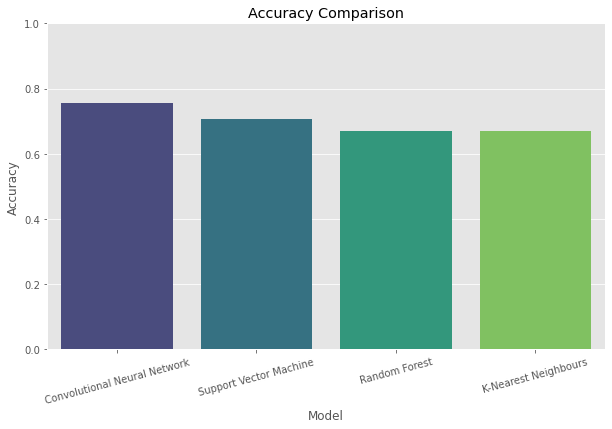

In [61]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=comparison,

    x="Model",

    y="Accuracy",

    palette="viridis"

)

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.title("Accuracy Comparison")

plt.show()

In [62]:
best_model = comparison.iloc[0]

print(best_model)

Model        Convolutional Neural Network
Accuracy                         0.755814
Precision                        0.749127
Recall                           0.755814
F1 Score                         0.734897
Name: 3, dtype: object


In [63]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
from tensorflow.keras.models import load_model
import numpy as np
import cv2

In [64]:
model = load_model("BananaLeafCNN.keras")

class_names = {
    0: "Healthy",
    1: "Segatoka",
    2: "Xamthomonas"
}

In [65]:
IMG_SIZE = 128

def predict_leaf(image_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    image = image.astype("float32") / 255.0

    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image, verbose=0)

    class_id = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    return class_names[class_id], confidence

In [66]:
def upload_image():

    file_path = filedialog.askopenfilename(
        filetypes=[
            ("Image Files", "*.jpg *.jpeg *.png")
        ]
    )

    if file_path:

        img = Image.open(file_path)

        img = img.resize((300, 250))

        img_tk = ImageTk.PhotoImage(img)

        image_label.config(image=img_tk)

        image_label.image = img_tk

        disease, confidence = predict_leaf(file_path)

        result_label.config(
            text=f"Prediction: {disease}\nConfidence: {confidence:.2f}%"
        )

In [67]:
root = tk.Tk()

root.title("Banana Leaf Disease Detection")

root.geometry("700x550")

root.resizable(False, False)

title_label = tk.Label(
    root,
    text="Banana Leaf Disease Detection System",
    font=("Helvetica", 18, "bold")
)

title_label.pack(pady=15)

image_label = tk.Label(root)

image_label.pack(pady=10)

upload_btn = tk.Button(
    root,
    text="Upload Banana Leaf Image",
    command=upload_image,
    font=("Helvetica", 12),
    bg="lightgreen",
    padx=15,
    pady=8
)

upload_btn.pack(pady=15)

result_label = tk.Label(
    root,
    text="Upload an image for prediction",
    font=("Helvetica", 14, "bold")
)

result_label.pack(pady=20)

root.mainloop()